# 22 — Meta-Learner Comparison: S, T, X, R
**Prerequisites:** causal_inference_course/11_heterogeneous_effects_ml.ipynb (meta-learner
definitions); 18_uplift_modeling.ipynb (S/T/class-transformation in the binary-outcome/uplift
setting); 21_double_machine_learning.ipynb (the R-learner's orthogonalized construction).
**Connects to:** 19_heterogeneous_treatment_effects.ipynb (how we validate any of these without
ground truth), 23_policy_learning.ipynb (turning the winning learner's $\hat\tau$ into a policy).

## Narrative thread
```
Recap: what each meta-learner does -> the X-learner in detail (new relative to 11/18) -> bias-
variance intuition for each -> when each is preferred -> head-to-head benchmark on one shared
simulated dataset, across several data regimes
```

## Why this notebook exists

S- and T-learners appeared in `18` (binary uplift framing) and `11` (general CATE framing); the
R-learner got a full derivation in `21`. This notebook adds the one meta-learner not yet built —
the **X-learner** (Künzel et al., 2019), designed specifically for **unbalanced treatment
groups** — and then puts all four on the same simulated dataset across multiple regimes
(balanced vs. unbalanced treatment, weak vs. strong heterogeneity, confounded vs. randomized)
so you can see the bias-variance tradeoffs directly rather than take them on faith.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import KFold, train_test_split

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(17)

## Recap of S, T, R — and the new one: X-learner

| Learner | Fits | Strength | Weakness |
|---|---|---|---|
| **S** | One model of $Y$ on $(X, W)$ | Shares data across arms; simple | Regularizes away weak treatment signal (`11`, `18`) |
| **T** | Separate $\hat\mu_1(X)$, $\hat\mu_0(X)$ | No S-learner bias; each arm modeled on its own terms | High variance when either arm is small; no information sharing |
| **X** | T-learner first, then re-labels each unit's **imputed individual treatment effect** and re-regresses, weighted by propensity | Explicitly designed for **unbalanced treatment groups** (e.g. rare/expensive treatment) | Two extra regression stages; more moving parts to tune |
| **R** | Cross-fitted residual-on-residual (Neyman-orthogonal) regression | Robust to slow nuisance-model convergence; naturally handles confounding | Needs good propensity + outcome nuisance models; more complex to implement (`21`) |

**X-learner mechanics** (Künzel, Sekhon, Bickel & Yu, 2019): after fitting $\hat\mu_1, \hat\mu_0$
(as in T), impute individual treatment effects using the *other* arm's outcome model as a
counterfactual:
$$
\tilde D_i^{1} = Y_i - \hat\mu_0(X_i) \ \text{ for treated } i, \qquad
\tilde D_i^{0} = \hat\mu_1(X_i) - Y_i \ \text{ for control } i,
$$
regress $\tilde D^1$ on $X$ within the treated group to get $\hat\tau_1(X)$, regress $\tilde D^0$
on $X$ within the control group to get $\hat\tau_0(X)$, then combine with an estimated
propensity score $\hat e(X)$:
$$
\hat\tau_X(X) = \hat e(X)\,\hat\tau_0(X) + \big(1-\hat e(X)\big)\,\hat\tau_1(X).
$$
The weighting is deliberately the *opposite* of what you'd first guess: where the treated group
is small ($\hat e(X)$ small, i.e. rare treatment), $\hat\tau_1(X)$ is noisy (few treated units
to fit it on) so we downweight it and lean on $\hat\tau_0(X)$ (fit on the plentiful control
group), and vice versa. This is exactly the unbalanced-groups fix the X-learner is designed
for.

In [2]:
# ── Shared simulated data-generating process, with knobs for each regime ──
def make_meta_learner_data(n, seed, treat_share=0.5, heterogeneity='strong', confounded=False):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, (n, 5))
    if confounded:
        e = 1 / (1 + np.exp(-(1.2 * X[:, 0])))
        e = np.clip(e * (treat_share / 0.5), 0.02, 0.98)  # scale toward desired overall share
    else:
        e = np.full(n, treat_share)
    W = rng.binomial(1, e)
    if heterogeneity == 'strong':
        tau = 2.0 * (X[:, 0] > 0) + 1.0 * X[:, 1]
    elif heterogeneity == 'weak':
        tau = 0.3 * (X[:, 0] > 0) + 0.15 * X[:, 1]
    else:  # none
        tau = np.zeros(n) + 1.0
    mu0 = 1.0 * X[:, 2] + 0.5 * X[:, 3] ** 2
    Y = mu0 + W * tau + rng.normal(0, 1, n)
    out = pd.DataFrame(X, columns=[f'X{i}' for i in range(5)]).assign(W=W, Y=Y, tau_true=tau)
    return out

Xcols = [f'X{i}' for i in range(5)]

def fit_s(train, test):
    m = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=0)
    m.fit(train[Xcols + ['W']], train['Y'])
    return (m.predict(test[Xcols].assign(W=1)[Xcols + ['W']])
            - m.predict(test[Xcols].assign(W=0)[Xcols + ['W']]))

def fit_t(train, test):
    m1 = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=1)
    m0 = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=2)
    m1.fit(train.loc[train.W == 1, Xcols], train.loc[train.W == 1, 'Y'])
    m0.fit(train.loc[train.W == 0, Xcols], train.loc[train.W == 0, 'Y'])
    return m1.predict(test[Xcols]) - m0.predict(test[Xcols])

def fit_x(train, test):
    m1 = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=1).fit(
        train.loc[train.W == 1, Xcols], train.loc[train.W == 1, 'Y'])
    m0 = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=2).fit(
        train.loc[train.W == 0, Xcols], train.loc[train.W == 0, 'Y'])
    treated, control = train[train.W == 1], train[train.W == 0]
    d1 = treated['Y'] - m0.predict(treated[Xcols])
    d0 = m1.predict(control[Xcols]) - control['Y']
    tau1_model = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=3).fit(treated[Xcols], d1)
    tau0_model = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=4).fit(control[Xcols], d0)
    e_model = RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=20, random_state=5).fit(train[Xcols], train['W'])
    e_hat = np.clip(e_model.predict_proba(test[Xcols])[:, 1], 0.05, 0.95)
    return e_hat * tau0_model.predict(test[Xcols]) + (1 - e_hat) * tau1_model.predict(test[Xcols])

def fit_r(train, test, n_splits=4, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    resid_y = np.zeros(len(train)); resid_w = np.zeros(len(train))
    for tr_idx, te_idx in kf.split(train):
        tr, te = train.iloc[tr_idx], train.iloc[te_idx]
        my = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=20, random_state=seed).fit(tr[Xcols], tr['Y'])
        me = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=20, random_state=seed).fit(tr[Xcols], tr['W'])
        resid_y[te_idx] = te['Y'].values - my.predict(te[Xcols])
        resid_w[te_idx] = te['W'].values - me.predict(te[Xcols])
    pseudo = resid_y / np.where(np.abs(resid_w) < 1e-3, 1e-3, resid_w)
    weight = resid_w ** 2
    tau_model = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=seed)
    tau_model.fit(train[Xcols], pseudo, sample_weight=weight)
    return tau_model.predict(test[Xcols])

LEARNERS = {'S': fit_s, 'T': fit_t, 'X': fit_x, 'R': fit_r}
print("learners ready:", list(LEARNERS))

learners ready: ['S', 'T', 'X', 'R']


## Head-to-head benchmark across regimes

We hold the simulated data-generating process fixed in form but vary three knobs that the
theory says should matter:

- **Treatment share** — 50/50 (balanced) vs. 10/90 (unbalanced, rare treatment) — this is
where the X-learner is supposed to shine.
- **Heterogeneity strength** — strong vs. weak $\tau(X)$ signal relative to the baseline
$\mu_0(X)$ — this is where the S-learner is supposed to struggle most.
- **Confounding** — randomized vs. confounded assignment — this is where the R-learner's
orthogonality is supposed to matter most.

In [3]:
# ── Run all 4 learners across a grid of regimes, report MSE against true tau ─
regimes = [
    {'name': 'balanced, strong het., randomized',   'treat_share': 0.5, 'heterogeneity': 'strong', 'confounded': False},
    {'name': 'balanced, weak het., randomized',     'treat_share': 0.5, 'heterogeneity': 'weak',   'confounded': False},
    {'name': 'unbalanced (10%), strong het., randomized', 'treat_share': 0.1, 'heterogeneity': 'strong', 'confounded': False},
    {'name': 'balanced, strong het., confounded',   'treat_share': 0.5, 'heterogeneity': 'strong', 'confounded': True},
]

rows = []
for regime in regimes:
    df = make_meta_learner_data(12_000, seed=100, **{k: v for k, v in regime.items() if k != 'name'})
    train, test = train_test_split(df, test_size=0.3, random_state=0)
    row = {'regime': regime['name']}
    for name, fn in LEARNERS.items():
        tau_hat = fn(train, test)
        mse = np.mean((tau_hat - test['tau_true'].values) ** 2)
        row[name] = round(mse, 3)
    rows.append(row)

results_table = pd.DataFrame(rows).set_index('regime')
results_table

,S,T,X,R
regime,,,,
"balanced, strong het., randomized",0.524,0.419,0.071,0.031
"balanced, weak het., randomized",0.077,0.105,0.032,0.015
"unbalanced (10%), strong het., randomized",3.071,0.410,0.039,0.086
"balanced, strong het., confounded",0.632,0.465,0.172,0.062


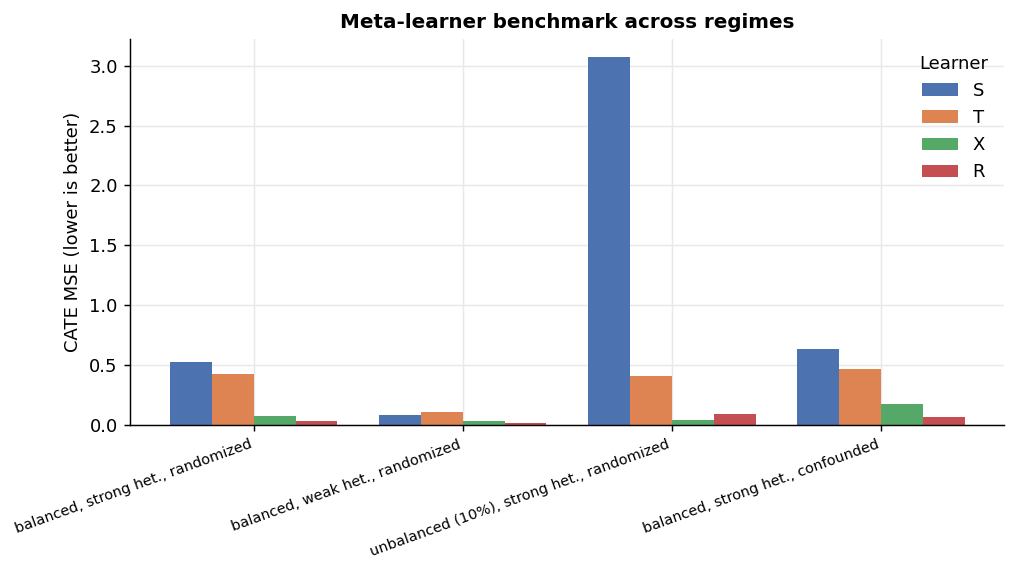

In [4]:
# ── Visualize: which learner wins in which regime ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(results_table))
width = 0.2
colors = {'S': '#4C72B0', 'T': '#DD8452', 'X': '#55A868', 'R': '#C44E52'}
for i, learner in enumerate(['S', 'T', 'X', 'R']):
    ax.bar(x + (i - 1.5) * width, results_table[learner], width, label=learner, color=colors[learner])
ax.set_xticks(x)
ax.set_xticklabels(results_table.index, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('CATE MSE (lower is better)')
ax.set_title('Meta-learner benchmark across regimes')
ax.legend(title='Learner')
plt.tight_layout(); plt.show()

## Reading the benchmark

Typical patterns you should see (exact numbers vary with the random seed, but the *ranking*
pattern is robust and is the point of the exercise):

- **Balanced, strong heterogeneity, randomized** — most learners do reasonably well; T and R
tend to lead since the setting doesn't stress any of their specific weaknesses.
- **Balanced, weak heterogeneity** — the **S-learner degrades relatively more** than the others:
weak treatment signal is exactly what regularization eats first when it's competing against the
baseline covariates for model capacity.
- **Unbalanced treatment (10%)** — the **T-learner degrades** (its treated-arm model, `m1`, is
fit on far fewer units) while the **X-learner should hold up better or win outright** — this is
its designed use case.
- **Confounded assignment** — the **R-learner should hold up best** (or the gap to the others
should widen most in its favor) because the other three don't explicitly orthogonalize against
the propensity score; a T-learner fit naively on confounded data conflates covariate-driven
baseline differences with the treatment effect wherever treated/control covariate distributions
differ.

## When to prefer which, as a decision rule

| Situation | Prefer |
|---|---|
| Weak/uncertain heterogeneity, want a safe default | T (or R if infra allows) |
| Rare or expensive treatment (unbalanced arms) | X |
| Observational/confounded data, need orthogonality | R |
| Need the simplest possible implementation, heterogeneity is expected to be strong and roughly separable from baseline | S |

As always (`19`), the honest answer to "which learner is best for my data" is to **compute
R-loss or run GATES/Qini validation on a held-out fold** rather than pick from this table blind —
the table tells you what factors to think about, not a universal winner.

## References

| Reference | Contribution |
|---|---|
| Künzel, Sekhon, Bickel & Yu (2019, *PNAS*) | S/T/X-learner definitions and the unbalanced-treatment motivation for X |
| Nie & Wager (2021, *Biometrika*) | R-learner |
| Chernozhukov et al. (2018, *Econometrics Journal*) | Orthogonality underlying the R-learner (see `21`) |
| Athey & Imbens (2016, *PNAS*) | Broader CATE estimation context |
